Name - RISHABH SHAH

Enrollment no. - 23SS02IT181

Subject - Image Processing

Subject code - SSCA4030

###Practical_7_Image_Restoration

In [ ]:
# Install required libraries

!pip install opencv-python numpy matplotlib pandas -q

print("Required libraries installed successfully!")

Required libraries installed successfully!


In [ ]:
from google.colab import files

uploaded = files.upload()

filename = list(uploaded.keys())[0]

print("Image uploaded successfully!")
print("File name:", filename)

Saving ChatGPT Image Aug 16, 2026, 11_05_26 PM.png to ChatGPT Image Aug 16, 2026, 11_05_26 PM.png
Image uploaded successfully!
File name: ChatGPT Image Aug 16, 2026, 11_05_26 PM.png


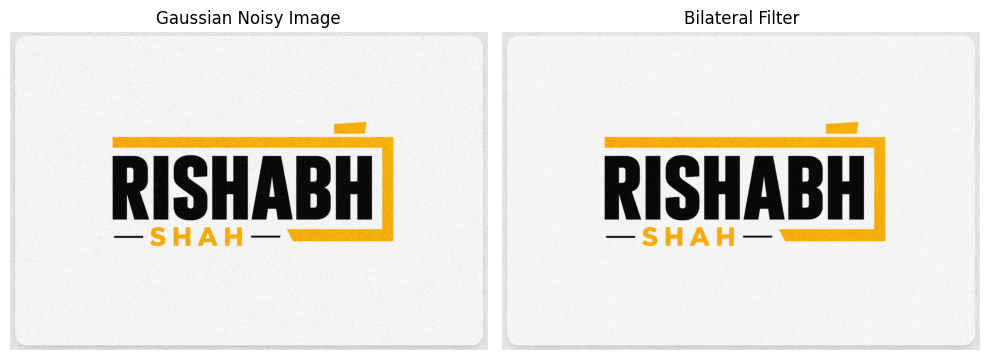

In [ ]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(gaussian_noisy_rgb)
plt.title("Gaussian Noisy Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(bilateral_filtered_rgb)
plt.title("Bilateral Filter")
plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# Import required libraries

import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
# Upload image from your computer

from google.colab import files

uploaded = files.upload()

# Get uploaded image filename
filename = list(uploaded.keys())[0]

print("Image uploaded successfully!")
print("File name:", filename)

Saving ChatGPT Image Aug 16, 2026, 11_05_26 PM.png to ChatGPT Image Aug 16, 2026, 11_05_26 PM (1).png
Image uploaded successfully!
File name: ChatGPT Image Aug 16, 2026, 11_05_26 PM (1).png


In [ ]:
image = cv2.imread(filename)

if image is None:
    raise FileNotFoundError("Image not found. Please upload a valid image.")

print("Image loaded successfully!")
print("Image Shape:", image.shape)

Image loaded successfully!
Image Shape: (1024, 1536, 3)


In [ ]:
# Read uploaded image

image = cv2.imread(filename)

# Check whether image was loaded successfully
if image is None:
    raise FileNotFoundError(
        "Image could not be loaded. Please upload a valid JPG or PNG image."
    )

# Convert BGR to RGB for Matplotlib
image_rgb = cv2.cvtColor(
    image,
    cv2.COLOR_BGR2RGB
)

print("Image loaded successfully!")
print("Image size:", image.shape)

Image loaded successfully!
Image size: (1024, 1536, 3)


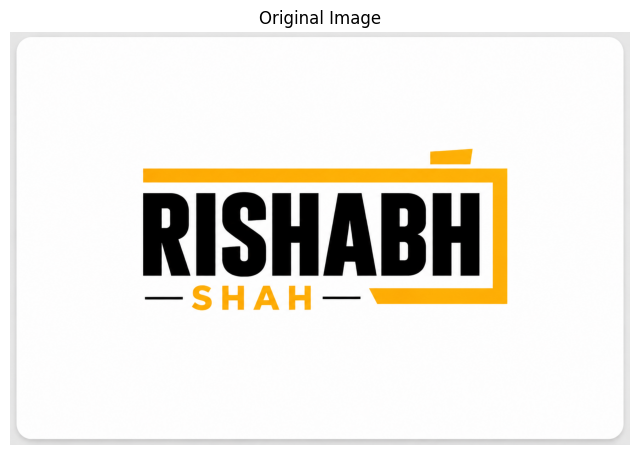

In [ ]:
# Display original image

plt.figure(figsize=(8, 6))

plt.imshow(image_rgb)

plt.title("Original Image")

plt.axis("off")

plt.show()

### PART A — Gaussian Noise

In [ ]:
# Function to add Gaussian noise

def add_gaussian_noise(image, mean=0, sigma=25):

    # Convert image to floating point
    image_float = image.astype(np.float32)

    # Generate Gaussian noise
    noise = np.random.normal(
        mean,
        sigma,
        image.shape
    )

    # Add noise to image
    noisy_image = image_float + noise

    # Keep pixel values between 0 and 255
    noisy_image = np.clip(
        noisy_image,
        0,
        255
    )

    # Convert back to uint8
    noisy_image = noisy_image.astype(np.uint8)

    return noisy_image


print("Gaussian noise function created successfully!")

Gaussian noise function created successfully!


In [ ]:
# Generate Gaussian noisy image

gaussian_noisy = add_gaussian_noise(
    image,
    mean=0,
    sigma=25
)

# Convert BGR to RGB
gaussian_noisy_rgb = cv2.cvtColor(
    gaussian_noisy,
    cv2.COLOR_BGR2RGB
)

print("Gaussian noise added successfully!")

Gaussian noise added successfully!


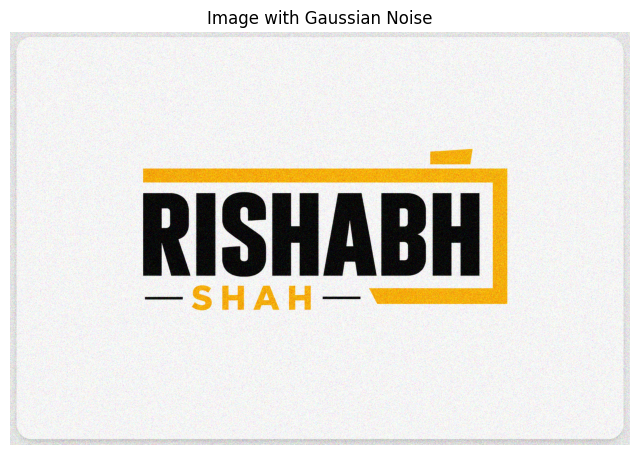

In [ ]:
# Display Gaussian noisy image

plt.figure(figsize=(8, 6))

plt.imshow(gaussian_noisy_rgb)

plt.title("Image with Gaussian Noise")

plt.axis("off")

plt.show()

### PART B — Salt-and-Pepper Noise

In [ ]:
# Function to add Salt-and-Pepper noise

def add_salt_pepper_noise(
    image,
    amount=0.05,
    salt_ratio=0.5
):

    # Create copy of original image
    noisy = image.copy()

    # Calculate total number of pixels
    total_pixels = (
        image.shape[0] *
        image.shape[1]
    )

    # Calculate number of noisy pixels
    num_noisy_pixels = int(
        amount * total_pixels
    )

    # -----------------------------
    # Salt Noise (White Pixels)
    # -----------------------------

    num_salt = int(
        num_noisy_pixels *
        salt_ratio
    )

    salt_y = np.random.randint(
        0,
        image.shape[0],
        num_salt
    )

    salt_x = np.random.randint(
        0,
        image.shape[1],
        num_salt
    )

    noisy[
        salt_y,
        salt_x
    ] = 255

    # -----------------------------
    # Pepper Noise (Black Pixels)
    # -----------------------------

    num_pepper = (
        num_noisy_pixels -
        num_salt
    )

    pepper_y = np.random.randint(
        0,
        image.shape[0],
        num_pepper
    )

    pepper_x = np.random.randint(
        0,
        image.shape[1],
        num_pepper
    )

    noisy[
        pepper_y,
        pepper_x
    ] = 0

    return noisy


print("Salt-and-Pepper noise function created successfully!")

Salt-and-Pepper noise function created successfully!


In [ ]:
# Generate Salt-and-Pepper noisy image

sp_noisy = add_salt_pepper_noise(
    image,
    amount=0.05,
    salt_ratio=0.5
)

# Convert BGR to RGB
sp_noisy_rgb = cv2.cvtColor(
    sp_noisy,
    cv2.COLOR_BGR2RGB
)

print("Salt-and-Pepper noise added successfully!")

Salt-and-Pepper noise added successfully!


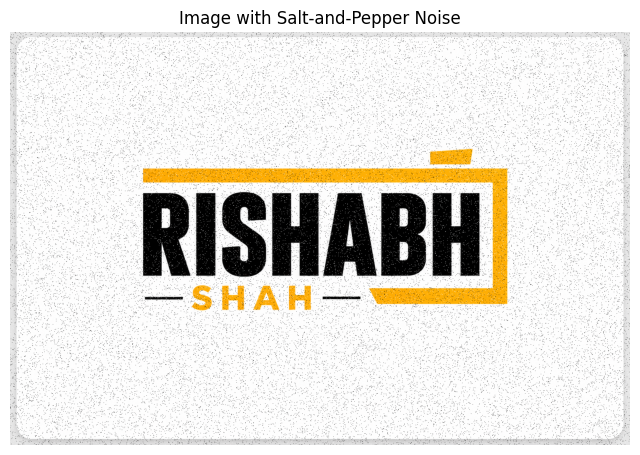

In [ ]:
# Display Salt-and-Pepper noisy image

plt.figure(figsize=(8, 6))

plt.imshow(sp_noisy_rgb)

plt.title("Image with Salt-and-Pepper Noise")

plt.axis("off")

plt.show()

### PART C — Image Restoration Using Filters

In [ ]:
# Apply Mean Filter

mean_filtered = cv2.blur(
    sp_noisy,
    (5, 5)
)

print("Mean filter applied successfully!")

Mean filter applied successfully!


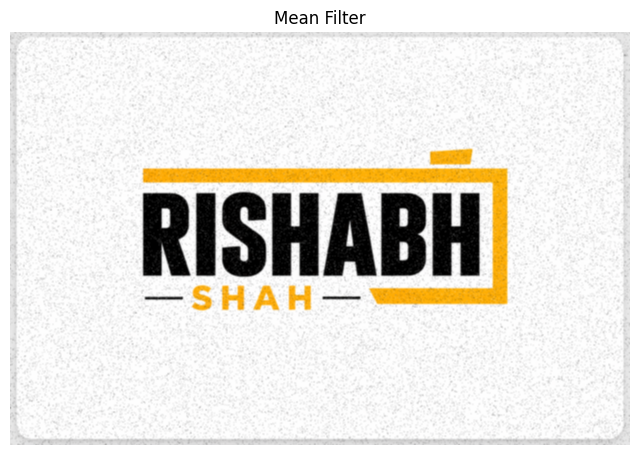

In [ ]:
# Display Mean Filter result

mean_filtered_rgb = cv2.cvtColor(
    mean_filtered,
    cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(8, 6))

plt.imshow(mean_filtered_rgb)

plt.title("Mean Filter")

plt.axis("off")

plt.show()

In [ ]:
# Apply Gaussian Filter

gaussian_filtered = cv2.GaussianBlur(
    gaussian_noisy,
    (5, 5),
    0
)

print("Gaussian filter applied successfully!")

Gaussian filter applied successfully!


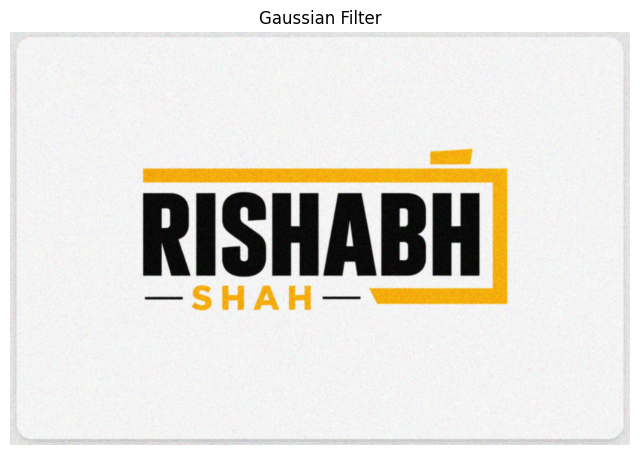

In [ ]:
# Convert to RGB

gaussian_filtered_rgb = cv2.cvtColor(
    gaussian_filtered,
    cv2.COLOR_BGR2RGB
)

# Display

plt.figure(figsize=(8, 6))

plt.imshow(gaussian_filtered_rgb)

plt.title("Gaussian Filter")

plt.axis("off")

plt.show()

In [ ]:
# Apply Median Filter

median_filtered = cv2.medianBlur(
    sp_noisy,
    5
)

print("Median filter applied successfully!")

Median filter applied successfully!


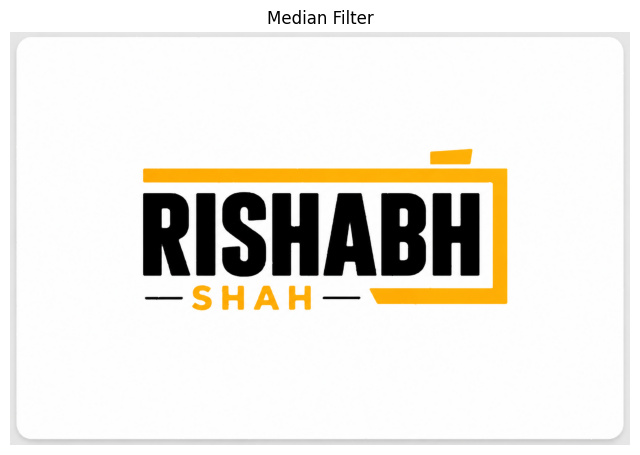

In [ ]:
# Convert to RGB

median_filtered_rgb = cv2.cvtColor(
    median_filtered,
    cv2.COLOR_BGR2RGB
)

# Display

plt.figure(figsize=(8, 6))

plt.imshow(median_filtered_rgb)

plt.title("Median Filter")

plt.axis("off")

plt.show()

In [ ]:
# Apply Bilateral Filter

bilateral_filtered = cv2.bilateralFilter(
    gaussian_noisy,
    9,
    75,
    75
)

print("Bilateral filter applied successfully!")

Bilateral filter applied successfully!


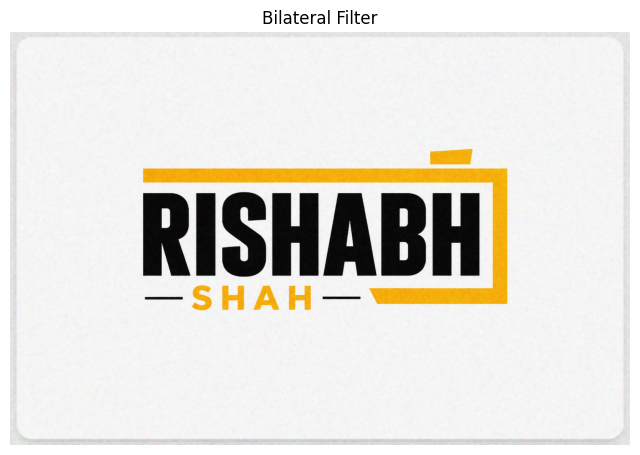

In [ ]:
# Convert to RGB

bilateral_filtered_rgb = cv2.cvtColor(
    bilateral_filtered,
    cv2.COLOR_BGR2RGB
)

# Display

plt.figure(figsize=(8, 6))

plt.imshow(bilateral_filtered_rgb)

plt.title("Bilateral Filter")

plt.axis("off")

plt.show()

### PART D — Compare All Images

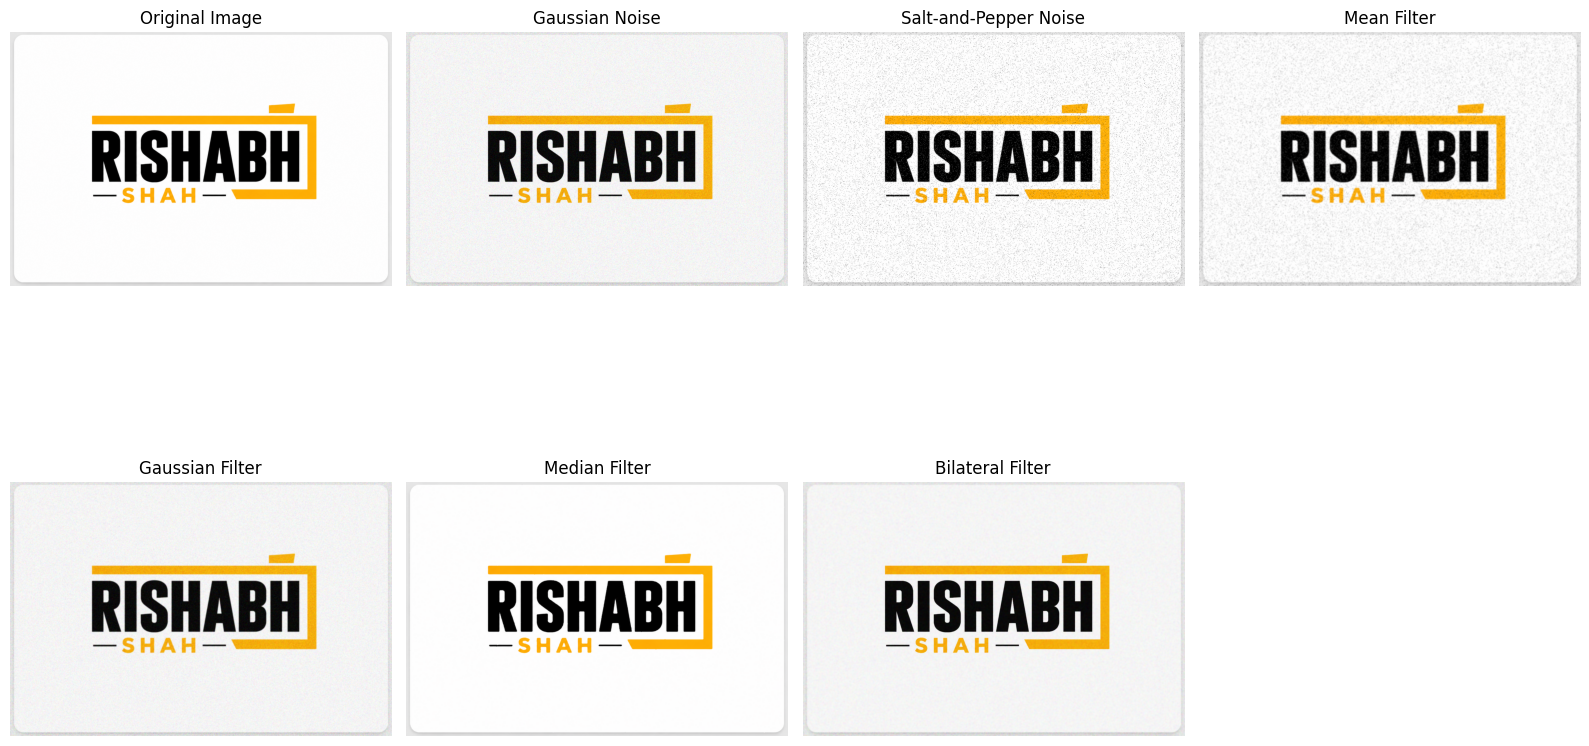

In [ ]:
# Display all results together

plt.figure(figsize=(16, 10))

# Original Image
plt.subplot(2, 4, 1)

plt.imshow(image_rgb)

plt.title("Original Image")

plt.axis("off")


# Gaussian Noise
plt.subplot(2, 4, 2)

plt.imshow(gaussian_noisy_rgb)

plt.title("Gaussian Noise")

plt.axis("off")


# Salt-and-Pepper Noise
plt.subplot(2, 4, 3)

plt.imshow(sp_noisy_rgb)

plt.title("Salt-and-Pepper Noise")

plt.axis("off")


# Mean Filter
plt.subplot(2, 4, 4)

plt.imshow(mean_filtered_rgb)

plt.title("Mean Filter")

plt.axis("off")


# Gaussian Filter
plt.subplot(2, 4, 5)

plt.imshow(gaussian_filtered_rgb)

plt.title("Gaussian Filter")

plt.axis("off")


# Median Filter
plt.subplot(2, 4, 6)

plt.imshow(median_filtered_rgb)

plt.title("Median Filter")

plt.axis("off")


# Bilateral Filter
plt.subplot(2, 4, 7)

plt.imshow(bilateral_filtered_rgb)

plt.title("Bilateral Filter")

plt.axis("off")


plt.tight_layout()

plt.show()

###PART E — MSE Calculation

In [ ]:
# Function to calculate MSE

def calculate_mse(original, restored):

    # Convert images to float
    original = original.astype(np.float32)

    restored = restored.astype(np.float32)

    # Calculate MSE
    mse = np.mean(
        (original - restored) ** 2
    )

    return mse


print("MSE function created successfully!")

MSE function created successfully!


###PART F — PSNR Calculation

In [ ]:
# Function to calculate PSNR

def calculate_psnr(original, restored):

    # Calculate MSE
    mse = calculate_mse(
        original,
        restored
    )

    # If MSE is zero
    if mse == 0:
        return float("inf")

    # Calculate PSNR
    psnr = 10 * np.log10(
        (255 ** 2) / mse
    )

    return psnr


print("PSNR function created successfully!")

PSNR function created successfully!


In [ ]:
# Mean Filter MSE and PSNR

mean_mse = calculate_mse(
    image,
    mean_filtered
)

mean_psnr = calculate_psnr(
    image,
    mean_filtered
)

print("Mean Filter")
print("-------------------------")
print("MSE  :", mean_mse)
print("PSNR :", mean_psnr, "dB")

Mean Filter
-------------------------
MSE  : 183.54889
PSNR : 25.493286 dB


In [ ]:
# Median Filter MSE and PSNR

median_mse = calculate_mse(
    image,
    median_filtered
)

median_psnr = calculate_psnr(
    image,
    median_filtered
)

print("Median Filter")
print("-------------------------")
print("MSE  :", median_mse)
print("PSNR :", median_psnr, "dB")

Median Filter
-------------------------
MSE  : 8.105476
PSNR : 39.04302 dB


In [ ]:
# Gaussian Filter MSE and PSNR

gaussian_mse = calculate_mse(
    image,
    gaussian_filtered
)

gaussian_psnr = calculate_psnr(
    image,
    gaussian_filtered
)

print("Gaussian Filter")
print("-------------------------")
print("MSE  :", gaussian_mse)
print("PSNR :", gaussian_psnr, "dB")

Gaussian Filter
-------------------------
MSE  : 145.6153
PSNR : 26.498734 dB


In [ ]:
# Bilateral Filter MSE and PSNR

bilateral_mse = calculate_mse(
    image,
    bilateral_filtered
)

bilateral_psnr = calculate_psnr(
    image,
    bilateral_filtered
)

print("Bilateral Filter")
print("-------------------------")
print("MSE  :", bilateral_mse)
print("PSNR :", bilateral_psnr, "dB")

Bilateral Filter
-------------------------
MSE  : 85.223694
PSNR : 28.8252 dB


###PART H — Final Comparison Table

In [ ]:
# Create comparison table

results = pd.DataFrame({

    "Filter": [
        "Mean Filter",
        "Median Filter",
        "Gaussian Filter",
        "Bilateral Filter"
    ],

    "MSE": [
        mean_mse,
        median_mse,
        gaussian_mse,
        bilateral_mse
    ],

    "PSNR (dB)": [
        mean_psnr,
        median_psnr,
        gaussian_psnr,
        bilateral_psnr
    ]
})

# Display table

print("IMAGE RESTORATION COMPARISON")
print("=" * 60)

display(results)

IMAGE RESTORATION COMPARISON


,Filter,MSE,PSNR (dB)
0,Mean Filter,183.548889,25.493286
1,Median Filter,8.105476,39.043018
2,Gaussian Filter,145.615295,26.498734
3,Bilateral Filter,85.223694,28.825199


In [ ]:
# Find filter with lowest MSE

best_mse_filter = results.loc[
    results["MSE"].idxmin(),
    "Filter"
]

# Find filter with highest PSNR

best_psnr_filter = results.loc[
    results["PSNR (dB)"].idxmax(),
    "Filter"
]

print("Best Filter according to MSE :")
print(best_mse_filter)

print()

print("Best Filter according to PSNR :")
print(best_psnr_filter)

Best Filter according to MSE :
Median Filter

Best Filter according to PSNR :
Median Filter
